In [1]:
# ---------- 1. IMPORTING LIBRARIES ----------
import pandas as pd                    # tables (DataFrames)
import numpy as np                     # maths functions
import matplotlib.pyplot as plt        # charts
from sklearn.ensemble import RandomForestRegressor   # model used to rank features

In [3]:
# ---------- 2. LOADING THE PREPROCESSED DATASET ----------
# ".." means "go up one folder", then into Data-preprocessing
df = pd.read_csv("../Data-preprocessing/Preprocessed_Meteorological_Dataset.csv")

print("Shape (rows, columns):", df.shape)   # expect (3317, 24)
df.head()                                    # first 5 rows

Shape (rows, columns): (3317, 24)


,Date,Dry_Morning,Wet_Morning,Dry_Evening,Wet_Evening,Max_Temperature,Min_Temperature,S. T. - 5cm Morning,S. T. - 10cm Morning,S. T. - 20cm Morning,...,S. T. - 30cm Evening,R. H. Morning,R. H. Evening,Mean Velocity,SunShine,Rainfall,Evaporation,Rainfall_Trace_Flag,Evaporation_Overflow_Flag,Wind_Direction_Encoded
0,2015-01-01,28.2,25.0,31.5,25.4,33.5,22.9,30.7,25.8,26.4,...,27.4,81.0,60.0,1.3,8.5,0.0,3.83,0.0,0.0,8
1,2015-01-02,28.2,25.0,31.5,25.4,33.5,22.9,30.7,26.8,27.8,...,27.8,83.0,62.0,1.6,7.0,0.0,1.99,0.0,0.0,5
2,2015-01-03,28.2,25.0,31.5,25.4,33.5,22.9,30.7,26.4,27.4,...,28.0,84.0,69.0,1.9,9.7,0.0,3.11,0.0,0.0,10
3,2015-01-04,28.2,25.0,31.5,25.4,33.5,22.9,30.7,27.2,28.0,...,28.2,88.0,65.0,1.8,8.4,0.0,2.71,0.0,0.0,8
4,2015-01-05,28.2,25.0,31.5,25.4,33.5,22.9,30.7,26.4,27.4,...,27.8,87.0,65.0,2.1,8.3,0.0,2.98,0.0,0.0,8


In [4]:
# ---------- 3. QUICK LOOK AT THE DATA ----------
print(df.dtypes)                    # data type of each column
print("\nMissing values:", df.isna().sum().sum())
print("Date range:", df["Date"].min(), "to", df["Date"].max())
df.describe().T                     # summary statistics per column

Date                             str
Dry_Morning                  float64
Wet_Morning                  float64
Dry_Evening                  float64
Wet_Evening                  float64
Max_Temperature              float64
Min_Temperature              float64
S. T. - 5cm Morning          float64
S. T. - 10cm Morning         float64
S. T. - 20cm Morning         float64
S. T. - 30cm Morning         float64
S. T. - 5cm Evening          float64
S. T. - 10cm Evening         float64
S. T. - 20cm Evening         float64
S. T. - 30cm Evening         float64
R. H. Morning                float64
R. H. Evening                float64
Mean Velocity                float64
SunShine                     float64
Rainfall                     float64
Evaporation                  float64
Rainfall_Trace_Flag          float64
Evaporation_Overflow_Flag    float64
Wind_Direction_Encoded         int64
dtype: object

Missing values: 0
Date range: 2015-01-01 to 2025-03-31


,count,mean,std,min,25%,50%,75%,max
Dry_Morning,3317.0,28.035831,4.031285,21.50,26.50,28.20,29.50,229.0
Wet_Morning,3317.0,24.935822,3.652234,19.50,24.20,25.00,25.50,225.0
Dry_Evening,3317.0,31.244528,2.892827,17.50,29.50,31.50,33.50,38.4
Wet_Evening,3317.0,25.365541,1.312346,2.20,24.50,25.40,26.00,35.5
Max_Temperature,3317.0,33.260733,2.592661,0.60,31.50,33.50,35.20,38.8
Min_Temperature,3317.0,22.644534,2.305943,2.50,21.50,22.90,24.20,33.5
S. T. - 5cm Morning,3317.0,30.631688,5.253156,22.50,28.90,30.70,32.10,303.0
S. T. - 10cm Morning,3317.0,28.746762,2.162541,2.00,27.20,28.80,30.40,36.0
S. T. - 20cm Morning,3317.0,30.007615,2.215535,3.40,28.20,30.00,31.80,35.6
S. T. - 30cm Morning,3317.0,30.747778,2.184027,3.40,29.50,31.00,32.00,39.7


In [5]:
# ---------- 4. MAKE A WORKING COPY AND SORT BY DATE ----------
data = df.copy()                                  # keep the original df untouched
data["Date"] = pd.to_datetime(data["Date"])       # turn text into real dates
data = data.sort_values("Date").reset_index(drop=True)   # oldest -> newest

TARGET = "Evaporation"      # the column we want to predict

In [6]:
# ---------- 5. CALENDAR FEATURES ----------
data["Month"]     = data["Date"].dt.month           # 1-12
data["DayOfYear"] = data["Date"].dt.dayofyear       # 1-366

# Sine/cosine put months and days on a circle,
# so December and January count as neighbours
data["Month_sin"] = np.sin(2 * np.pi * data["Month"] / 12)
data["Month_cos"] = np.cos(2 * np.pi * data["Month"] / 12)
data["DOY_sin"]   = np.sin(2 * np.pi * data["DayOfYear"] / 365)
data["DOY_cos"]   = np.cos(2 * np.pi * data["DayOfYear"] / 365)

In [7]:
# ---------- 6. TEMPERATURE FEATURES ----------
data["Temp_Mean"]  = (data["Max_Temperature"] + data["Min_Temperature"]) / 2   # average temperature
data["Temp_Range"] = data["Max_Temperature"] - data["Min_Temperature"]         # daily swing

# Dry-bulb minus wet-bulb: a bigger gap means drier air
data["Depression_Morning"] = data["Dry_Morning"] - data["Wet_Morning"]
data["Depression_Evening"] = data["Dry_Evening"] - data["Wet_Evening"]
data["Depression_Mean"]    = (data["Depression_Morning"] + data["Depression_Evening"]) / 2

In [8]:
# ---------- 7. HUMIDITY AND VAPOUR PRESSURE DEFICIT (VPD) ----------
data["RH_Mean"] = (data["R. H. Morning"] + data["R. H. Evening"]) / 2   # average humidity (%)
data["RH_Diff"] = data["R. H. Morning"] - data["R. H. Evening"]         # morning minus evening

def sat_vp(t):
    """Saturation vapour pressure (kPa) from air temperature t in degrees C."""
    return 0.6108 * np.exp(17.27 * t / (t + 237.3))

# VPD = how much more moisture the air could still absorb ("thirst" of the air)
data["VPD_Morning"] = sat_vp(data["Dry_Morning"]) * (1 - data["R. H. Morning"] / 100)
data["VPD_Evening"] = sat_vp(data["Dry_Evening"]) * (1 - data["R. H. Evening"] / 100)
data["VPD_Mean"]    = (data["VPD_Morning"] + data["VPD_Evening"]) / 2

In [9]:
# ---------- 8. SOIL TEMPERATURE FEATURES ----------
soil_morning = ["S. T. - 5cm Morning", "S. T. - 10cm Morning", "S. T. - 20cm Morning", "S. T. - 30cm Morning"]
soil_evening = ["S. T. - 5cm Evening", "S. T. - 10cm Evening", "S. T. - 20cm Evening", "S. T. - 30cm Evening"]

data["Soil_Mean_Morning"] = data[soil_morning].mean(axis=1)   # average over 4 depths
data["Soil_Mean_Evening"] = data[soil_evening].mean(axis=1)
data["Soil_Gradient_Eve"] = data["S. T. - 5cm Evening"] - data["S. T. - 30cm Evening"]  # surface vs deep
data["Soil_Air_Diff"]     = data["S. T. - 5cm Evening"] - data["Dry_Evening"]           # soil vs air

In [10]:
# ---------- 9. COMBINED-EFFECT FEATURES ----------
data["Temp_x_Sun"] = data["Temp_Mean"] * data["SunShine"]       # hot AND sunny
data["Wind_x_VPD"] = data["Mean Velocity"] * data["VPD_Mean"]   # windy AND dry air
data["Rain_Flag"]  = (data["Rainfall"] > 0).astype(int)         # 1 = it rained, 0 = it did not

In [11]:
# ---------- 10. RECENT-PAST FEATURES (no peeking at today) ----------
def past_window(col, days, how):
    """Sum/mean of `col` over the previous `days` calendar days, EXCLUDING today.
    Needs at least 60% of those days to exist, otherwise NaN (days are missing)."""
    s = data.set_index("Date")[col]
    r = s.rolling(f"{days}D", closed="left", min_periods=1)   # closed="left" excludes today
    stat = getattr(r, how)()
    stat[r.count() < 0.6 * days] = np.nan
    return stat.to_numpy()

data["Rain_lag1"]    = past_window("Rainfall", 1, "sum")     # rain yesterday
data["Rain_sum_3d"]  = past_window("Rainfall", 3, "sum")
data["Rain_sum_7d"]  = past_window("Rainfall", 7, "sum")
data["Rain_sum_14d"] = past_window("Rainfall", 14, "sum")
data["Temp_mean_7d"] = past_window("Temp_Mean", 7, "mean")
data["VPD_mean_7d"]  = past_window("VPD_Mean", 7, "mean")
data["Sun_mean_7d"]  = past_window("SunShine", 7, "mean")

# Remove rows that have no usable history (start of data, after gaps)
before = len(data)
data = data.dropna().reset_index(drop=True)
print("Rows dropped:", before - len(data), "| Rows left:", len(data))
print("First date now:", data["Date"].min().date())

Rows dropped: 82 | Rows left: 3235
First date now: 2015-01-10


In [12]:
# ---------- 11. WIND DIRECTION (label-encoded -> one-hot) ----------
wind = "Wind_Direction_Encoded"
print(data[wind].value_counts().sort_index())      # how often each code occurs

# Codes are labels, not amounts. Rare codes (<100 days) go into one "Other" group
counts = data[wind].value_counts()
common_codes = counts[counts >= 100].index
data["Wind_Group"] = np.where(data[wind].isin(common_codes), data[wind].astype(str), "Other")

# One yes/no column per wind group
data = pd.get_dummies(data, columns=["Wind_Group"], prefix="Wind", drop_first=True, dtype=int)
data = data.drop(columns=[wind])                   # remove the original code column
print([c for c in data.columns if c.startswith("Wind_")])

Wind_Direction_Encoded
0       84
1       88
2       29
3       34
4       69
5      334
6       14
7       20
8      329
9      237
10     378
11      43
12      60
13    1148
14      39
15     160
16      75
17      94
Name: count, dtype: int64
['Wind_x_VPD', 'Wind_13', 'Wind_15', 'Wind_5', 'Wind_8', 'Wind_9', 'Wind_Other']


In [13]:
# ---------- 12. CANDIDATE FEATURES ----------
# Leave out: Date (not a number), the target itself, and the constant overflow flag
exclude = ["Date", TARGET, "Evaporation_Overflow_Flag"]
features = [c for c in data.columns if c not in exclude]

print(len(features), "candidate features")
print("Columns that never change:", [c for c in features if data[c].nunique() == 1])

56 candidate features
Columns that never change: []


In [14]:
# ---------- 13. TIME-BASED TRAIN/TEST SPLIT ----------
# First 80% of dates = training, last 20% = testing (we predict the future from the past)
split = int(len(data) * 0.8)
print("Training rows:", split, "| Test rows:", len(data) - split)
print("Training ends on:", data["Date"].iloc[split - 1].date())
print("Test starts on:  ", data["Date"].iloc[split].date())

Training rows: 2588 | Test rows: 647
Training ends on: 2023-05-04
Test starts on:   2023-05-05


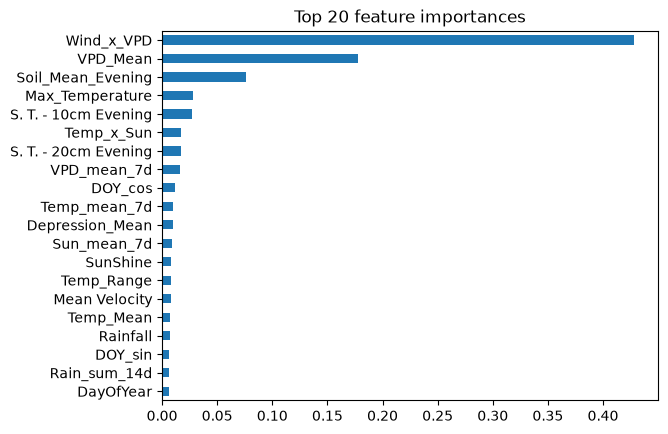

Wind_x_VPD              0.428530
VPD_Mean                0.177352
Soil_Mean_Evening       0.076280
Max_Temperature         0.028199
S. T. - 10cm Evening    0.026819
Temp_x_Sun              0.017307
S. T. - 20cm Evening    0.016949
VPD_mean_7d             0.016049
DOY_cos                 0.011696
Temp_mean_7d            0.009906
Depression_Mean         0.009597
Sun_mean_7d             0.009413
SunShine                0.008463
Temp_Range              0.008213
Mean Velocity           0.007684
Temp_Mean               0.007609
Rainfall                0.006913
DOY_sin                 0.006622
Rain_sum_14d            0.006387
DayOfYear               0.006357
dtype: float64

In [15]:
# ---------- 14. FEATURE IMPORTANCE (TRAINING DATA ONLY) ----------
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(data[features].iloc[:split], data[TARGET].iloc[:split])   # learn from training part only

importance = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

importance.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 feature importances")
plt.show()
importance.head(20)

In [16]:
# ---------- 15. FINAL FEATURE LIST ----------
final_features = importance.head(15).index.tolist()
print(final_features)

['Wind_x_VPD', 'VPD_Mean', 'Soil_Mean_Evening', 'Max_Temperature', 'S. T. - 10cm Evening', 'Temp_x_Sun', 'S. T. - 20cm Evening', 'VPD_mean_7d', 'DOY_cos', 'Temp_mean_7d', 'Depression_Mean', 'Sun_mean_7d', 'SunShine', 'Temp_Range', 'Mean Velocity']


In [17]:
# ---------- 16. SAVE THE ENGINEERED DATASETS ----------
data[["Date"] + features + [TARGET]].to_csv("Engineered_Dataset_Full.csv", index=False)         # all candidates
data[["Date"] + final_features + [TARGET]].to_csv("Engineered_Dataset.csv", index=False)        # top 15 only
print("Saved.")

Saved.


In [ ]:
## Feature engineering decisions
- Input: Preprocessed_Meteorological_Dataset.csv (3,317 rows, 24 columns). 2018 was removed in preprocessing and the first 5 rows were mean-imputed.
- Created new columns: calendar (sin/cos), temperature, humidity and VPD, soil, combined effects, recent-past summaries, and grouped wind direction.
- Recent-past features use only earlier days (today excluded) and need at least 60% of the window's days to exist.
- Excluded Evaporation_Overflow_Flag (constant, overflow rows were removed) and Year (test years are unseen).
- Wind direction codes are labels, so they were one-hot encoded and rare codes grouped into "Other".
- Top 15 features chosen by a random forest trained on the earlier 80% of dates only.
- No scaling here; the modelling step should scale inside its training pipeline.